<img src="https://www.digi-hand.de/wp-content/themes/hitchcock/images/logo-tu-iwf.png" align='right' width="20%">
<a name="divtop"></a> 

## Zeitreihenanalyse basierend auf Eigenwertextraktion des YOLOv8-Modells

                                                                                         nur für Videosdaten                                                   —————————————————————————————————————————————————————————————————————————————————————————————————————————————

**Autor**: Gefertec Gruppe_WS22 | **Letztes Update**: 04. Mai 2023

<div class="alert alert-block" style="background-color: #90EE90">
<font color=green>

### Notebook-Ziele
In Zusammenarbeit mit der Pipeline für Zeitreihenanalyse werden wir:

- Infomation von Point extrahieren
- Kennzahlen extrahieren
- Animation mit matplotlib machen
   
</font> 
    
</div>

## Inhaltsverzeichnis

* [Einführung](#introduction)
* [Importe](#imports)
* [Komfortfunktionen](#function)
* [Die gesamte Pipeline ausführen ](#pipeline)
    - [Step 1: Laden das Modell zur Segmentierung und Erkennung mit YOLOv8](#step1)
    - [Step 2: Infomation von Punkten extrahieren](#step2)
    - [Step 3: Kennzahlen extrahieren/ Umrechnen und einzel darstellen](#step3)
    - [Step 4: Einheite: Pixelwert zu MM transportieren](#step4)
    - [Step 5: Animation mit matplotlib](#step5)


<a id='introduction'></a>
### **Einführung**

Dieses Notebook behandelt die Zeitreihenanalysespipeline für das Projekt von Gefertec.

Installation: Sie benötigen die Installation von YOLOv8, OpenCV, Programmierungsprache(OpenCV-Python), IDE(Anaconda).

Ziel von "Zeitreihenanalyse": 
1. Extrahieren Bildinformationen aus Videos
2. Steuern den Produktionsprozess durch die Variation der drei extrahierten Parameter


<a id='imports'></a>
### **Importe**
Für dieses Notebook erforderliche Pakete importieren:




In [1]:
# Base
import cv2
import glob
import numpy as np
import os
import torch
import math

# Modul
from ultralytics import YOLO

# Visualisieren
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.animation as animation

from matplotlib import pyplot as plt
from matplotlib import animation
import matplotlib.animation as animation

d:\anaconda\anaconda\envs\yolov8\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir("/Users/xuhao/AUT_idee_BoxPlot/outputdata/")

<a id='function'></a>
### **Komfortfunktionen**




Hier definieren wir einige Funktionen und einige Parameter, die wir im gesamten Notebook wiederholt verwenden werden.


In [ ]:
def get_Schmelzbad_poly(results):
    '''
    Schmelzbad Polygon Punkte
    '''

    num_elements = len(results) 
    Schmelzbad_poly = np.empty(num_elements, dtype=object)
    Area_S = np.empty(num_elements, dtype=object)
    Area_L = np.empty(num_elements, dtype=object)
    Length_L = np.empty(num_elements)                              

    for i in range(num_elements):
        masks = results[i].masks
        if masks is None:
            Schmelzbad_poly[i] = []
            continue
        points = masks.xy
        boxes = results[i].boxes
        orig_cls = boxes.cls  # take the class from result
        cpu_cls = orig_cls.cpu()
        np_cls = cpu_cls.numpy()  # transform Tensor to numpy
        unique_elements = np.unique(np_cls)
        element_to_find_schmelzbad = 1  # the label of Schmelzbad 

        if np.isin(element_to_find_schmelzbad, unique_elements):  # check if there are empty numpy array
            index = np.where(np_cls == element_to_find_schmelzbad)[0]
            polygon_points = [points[i] for i in index]
        else:
            polygon_points = []  # if the array is empty, give it an empty array     #!!!! neu
        Schmelzbad_poly[i] = polygon_points  # store polygon points in this No.i frame


    return Schmelzbad_poly

In [ ]:
def get_Lichtbogen_poly(results):
    '''
    Lichtbogen Polygon Punkte
    '''
    num_elements = len(results) 
    Lichtbogen_poly = np.empty(num_elements, dtype=object)
    Area_S = np.empty(num_elements, dtype=object)
    Area_L = np.empty(num_elements, dtype=object)
    Length_L = np.empty(num_elements)                              

    for i in range(num_elements):
        masks = results[i].masks
        if masks is None:
            Lichtbogen_poly[i] = []
            continue
        points = masks.xy
        boxes = results[i].boxes
        orig_cls = boxes.cls  # take the class from result
        cpu_cls = orig_cls.cpu()
        np_cls = cpu_cls.numpy()  # transform Tensor to numpy
        unique_elements = np.unique(np_cls)  
        element_to_find_Lichtbogen = 0  # the label of Lichtbogen   

        if np.isin(element_to_find_Lichtbogen, unique_elements):  # check if there are empty numpy array
            index = np.where(np_cls == element_to_find_Lichtbogen)[0]
            polygon_points = [points[i] for i in index]
        else:
            polygon_points = []  # if the array is empty, give it an empty array      #!!!! neu
        Lichtbogen_poly[i] = polygon_points  # store polygon points in this No.i frame

    return Lichtbogen_poly

In [3]:
def get_Spritzer_anzahl(results):
    '''
    Anzahl des Spritzer:
    '''
    num_elements = len(results)
    spritzer_num = np.zeros(num_elements)

    for i in range(num_elements):
        boxes = results[i].boxes
        orig_cls = boxes.cls   #take the class from result
        cpu_cls = orig_cls.cpu()
        np_cls = cpu_cls.numpy()   #transform Tensor to numpy
        unique_elements, counts = np.unique(np_cls, return_counts=True)
        element_to_find = 4   #the label of Spritzer
        if np.isin(element_to_find,unique_elements):   #check if there are empty numpy array
            index = np.where(unique_elements == element_to_find)
            count = counts[index]
        else:
            count = np.array([0])   # if the array is empty, give it a zero
        spritzer_num[i] = count   #input a count of Spritzer in this No.i frame
    return spritzer_num

In [4]:
def get_schmelzbad_laenge(Schmelzbad_poly):
    '''
    Länge des Schmelzbad:
    '''
    differences = []
    for i in range(len(Schmelzbad_poly)):

        poly = Schmelzbad_poly[i]

        if len(poly)==1:
            poly = poly[0]

            first_elements = poly[:, 0]
            max_value = np.max(first_elements)
            min_value = np.min(first_elements)
            difference = max_value - min_value
            differences.append(difference)
        elif len(poly)>1:
            poly = max(poly,key = len)
            first_elements = poly[:, 0]
            max_value = np.max(first_elements)
            min_value = np.min(first_elements)
            difference = max_value - min_value
            differences.append(difference)
        elif len(poly)== 0:
            differences.append(0)
    return differences

In [5]:
def get_schmelzbad_area(Schmelzbad_poly):
    '''
    Die Flächen des Schmelzbads:
    '''
    area=[]
    for i in range(len(Schmelzbad_poly)):
        poly = Schmelzbad_poly[i]
        if len(poly)==1:
            poly = poly[0]
            area.append(cv2.contourArea(poly))
        elif len(poly)>1:
            poly = max(poly,key = len)
            area.append(cv2.contourArea(poly))
        elif len(poly)== 0:
            area.append(0)
    return area

In [6]:
def get_schmelzbad_cir(Schmelzbad_poly):
    '''
    Umfang des Schmelzbads:
    '''
    circumference=[]
    for i in range(len(Schmelzbad_poly)):
        poly = Schmelzbad_poly[i]
        if len(poly)==1:
            poly = poly[0]
            circumference.append(cv2.arcLength(poly,True))
        elif len(poly)>1:
            poly = max(poly,key = len)
            circumference.append(cv2.arcLength(poly,True))
        elif len(poly)== 0:
            circumference.append(0)
    return   circumference 

In [7]:
def get_lichtbogen_area(Lichtbogen_poly):
    '''
    Flächen der Lichtbogen:
    '''
    area_lichtbogen=[]
    for i in range(len(Lichtbogen_poly)):
        poly = Lichtbogen_poly[i]
        if len(poly)==1:
            poly = poly[0]
            area_lichtbogen.append(cv2.contourArea(poly))
        elif len(poly)>1:
            poly = max(poly,key = len)
            area_lichtbogen.append(cv2.contourArea(poly))
        elif len(poly)== 0:
            area_lichtbogen.append(0)
    return area_lichtbogen

In [8]:
def get_abteilung_diagramm(y):
    '''
    Die Änderung der beliebiger Kennzahl:
    '''    
    x = np.linspace(0, len(y), len(y))
    dy = np.diff(y) / np.diff(x)
    return dy

In [9]:
def get_real_size_1D(pixel_array):
    '''
    real size: Kx,Ky -> Deteils sieht in Bericht!
    Hier gilt nur Länge oder Durchmesser oder Umfang
    '''
    Kx=0.0746
    Ky=0.0736
    real_size=[]
    for i in range(len(pixel_array)):
        real_size.append(pixel_array[i]*Kx)
    return real_size

In [10]:
def get_real_size_2D(pixel_array):
    '''
    real size: Kx,Ky -> Deteils sieht in Bericht!
    
    '''
    Kx=0.0746
    Ky=0.0736
    real_size=[]
    for i in range(len(pixel_array)):
        real_size.append(pixel_array[i]*Kx*Ky)
    return real_size

[Top of Notebook](#divtop)

<a id='pipeline'></a>
### **Die gesamte Pipeline ausführen**

<a id='step1'></a>
#### **Step 1: Laden das Modell zur Segmentierung und Erkennung mit YOLOv8**

-Hier gibt es 2 Modul anrufen, weil Spritzer nur für "detection" führt, aber Schmelzbad und Lichtbogen für "segment" führen.

##### **Segmentation Modell**

In [118]:
# "segment" model führen: Schmelzbad und Lichtbogen:
if __name__ == '__main__':
# Load a Pamarmeter
    model = YOLO("best_v8m.pt") 
# Predict with the model: hier ist Video
    results = model(source='Video_1_Sampel_152743_356_482',save=True,iou = 0.1,conf=0.5,boxes=True,retina_masks=True);


image 1/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/356.jpg: 512x640 (no detections), 637.3ms
image 2/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/357.jpg: 512x640 (no detections), 437.0ms
image 3/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/358.jpg: 512x640 1 Lichtbogen, 491.7ms
image 4/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/359.jpg: 512x640 1 Lichtbogen, 432.7ms
image 5/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/360.jpg: 512x640 1 Lichtbogen, 437.0ms
image 6/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/361.jpg: 512x640 1 Lichtbogen, 470.3ms
image 7/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/362.jpg: 512x640 (no detections), 451.1ms
image 8/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/363.jpg: 512x640 1 Schmelzbad, 542.0ms
image 9/127 /U

image 67/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/422.jpg: 512x640 1 Lichtbogen, 1 Schmelzbad, 498.2ms
image 68/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/423.jpg: 512x640 1 Lichtbogen, 1 Schmelzbad, 474.7ms
image 69/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/424.jpg: 512x640 1 Schmelzbad, 485.4ms
image 70/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/425.jpg: 512x640 1 Schmelzbad, 486.5ms
image 71/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/426.jpg: 512x640 1 Lichtbogen, 1 Schmelzbad, 467.2ms
image 72/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/427.jpg: 512x640 1 Schmelzbad, 446.1ms
image 73/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482/428.jpg: 512x640 1 Lichtbogen, 1 Schmelzbad, 471.2ms
image 74/127 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_356_482

##### **Detektion Modell**

In [136]:
# # "detection" model führen: Spritzer
if __name__ == '__main__':
# Load a models Parameter
    model2= YOLO("best_spritzer.pt") 
# Predict with the model
    results2 = model2(source='Video_1_Sampel_152743_380_500',save=True,iou = 0.1,conf=0.5,boxes=True,retina_masks=True);


image 1/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0380.jpg: 512x640 1 Draht, 1 Schmelzbad, 1 Spritzer, 220.9ms
image 2/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0381.jpg: 512x640 1 Draht, 1 Lichtbogen, 261.7ms
image 3/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0382.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 234.2ms
image 4/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0383.jpg: 512x640 1 Draht, 1 Schmelzbad, 1 Spritzer, 182.4ms
image 5/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0384.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 213.3ms
image 6/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0385.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 288.8ms
image 7/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0386.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzb

image 59/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0438.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 208.9ms
image 60/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0439.jpg: 512x640 1 Draht, 1 Schmelzbad, 190.2ms
image 61/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0440.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 238.6ms
image 62/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0441.jpg: 512x640 1 Draht, 1 Schmelzbad, 231.0ms
image 63/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0442.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 221.1ms
image 64/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0443.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 236.6ms
image 65/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0444.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 

image 118/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0497.jpg: 512x640 1 Draht, 1 Schmelzbad, 226.2ms
image 119/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0498.jpg: 512x640 1 Draht, 1 Schmelzbad, 219.6ms
image 120/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0499.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 210.3ms
image 121/121 /Users/xuhao/AUT_idee_BoxPlot/outputdata/Video_1_Sampel_152743_380_500/_0500.jpg: 512x640 1 Draht, 1 Lichtbogen, 1 Schmelzbad, 250.4ms
Speed: 2.3ms preprocess, 218.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/xuhao/runs/detect/predict7


<a id='step2'></a>
#### **Step 2: Infomation von Punkten extrahieren**

Weil der Code zum Extrahieren von Datenpunkten bereits gekapselt wurde, wird er hier direkt aufgerufen:

In [ ]:
Schmelzbad_poly = get_Schmelzbad_poly(results)
Lichtbogen_poly = get_Lichtbogen_poly(results)

[Top of Notebook](#divtop)

<a id='step3'></a>
#### **Step 3:  Kennzahlen extrahieren/ Umrechnen und einzel darstellen**
##### **Kennzahlen extrahieren**
**Schmelzbad:**

In [120]:
# Länge[in Pixel]
schmelz_laenge = get_schmelzbad_laenge(Schmelzbad_poly)
# Länge[in mm]
schmelzbad_laenge_mm=get_real_size_1D(schmelz_laenge)

In [121]:
# Flächen[in Pixel^2]
schmelzbad_area = get_schmelzbad_area(Schmelzbad_poly)
# Flächen[in mm^2]
schmelzbad_area_mm=get_real_size_2D(schmelzbad_area)
max(schmelzbad_area_mm)

537.79760672

In [22]:
# Umfang [in Pixel]
schmelzbad_cir = get_schmelzbad_cir(Schmelzbad_poly)

**Lichtbogen:**

In [130]:
# Flächen[in Pixel^2]
lichtbogen_area = get_lichtbogen_area(Lichtbogen_poly)
# Flächen[in mm^2]
lichtbogen_area_mm = get_real_size_2D(lichtbogen_area)
max(lichtbogen_area_mm)

357.89117247999997

**Spritzer:**

In [137]:
# Anzahl[in Num]
spritzer_anzahl = get_Spritzer_anzahl(results2)
#spritzer_anzahl

##### **Einzel Plotting**
**Schmelzbad:**

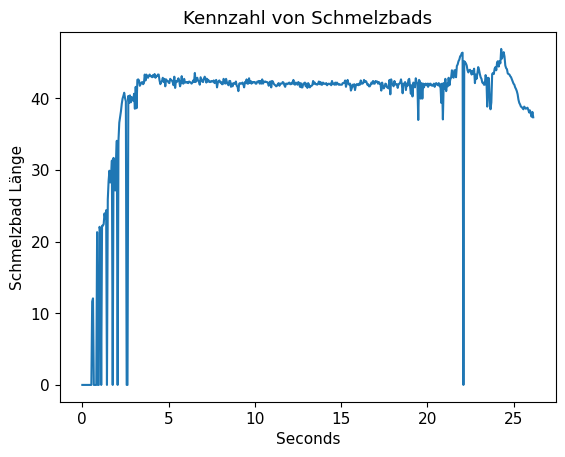

In [28]:
#Länger
%matplotlib inline
seconds = [i/21 for i in range(len(schmelzbad_laenge_mm))] # [in Sekunde]
plt.plot(seconds[:], schmelzbad_laenge_mm[:])
plt.xlabel('Seconds')
plt.ylabel('Schmelzbad Länge')
plt.title('Kennzahl von Schmelzbads')
plt.show()

<IPython.core.display.Javascript object>


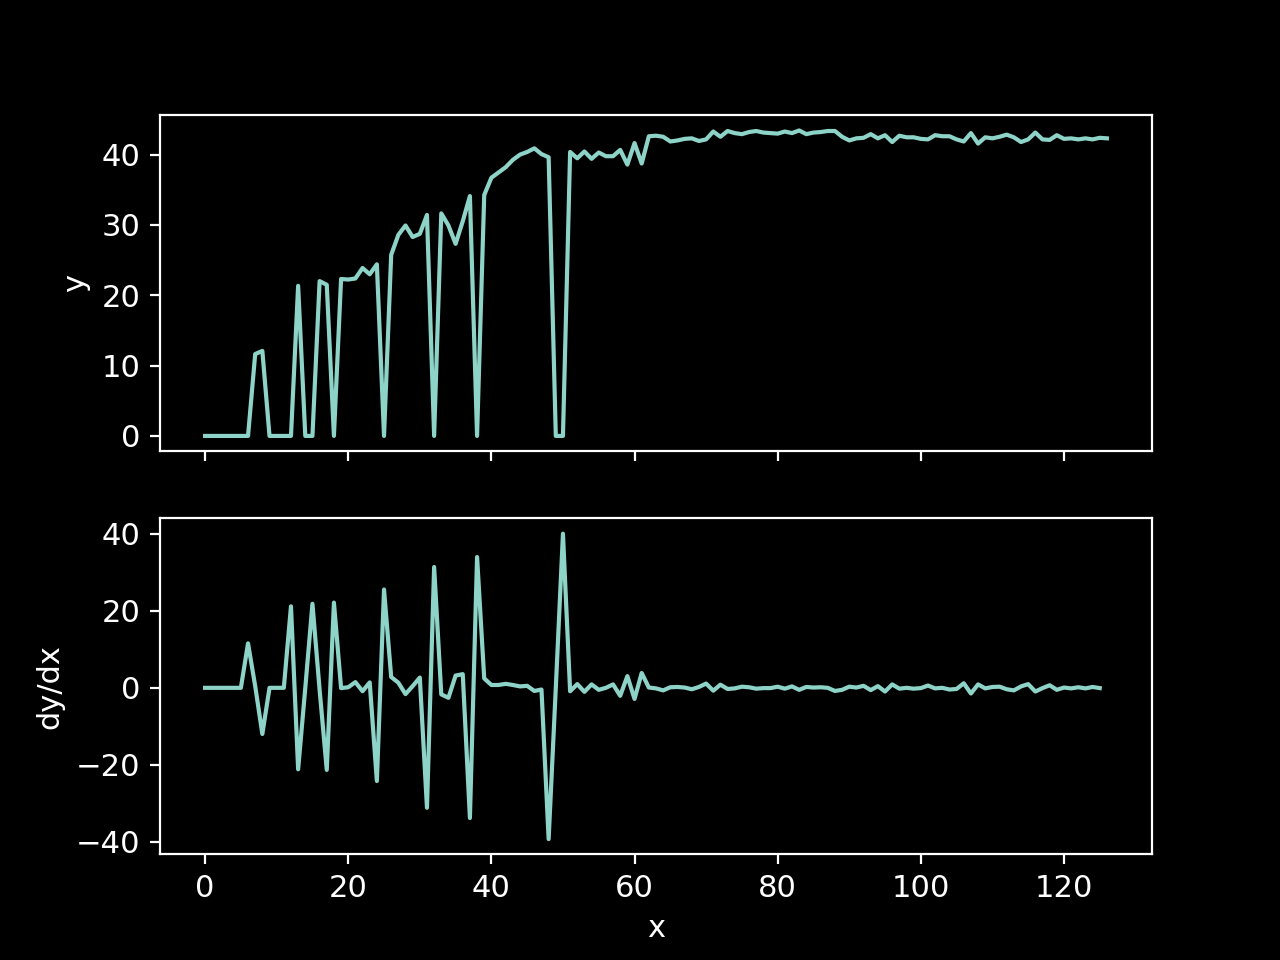

In [125]:
# 1.ABTEILUNG：
dy_schmelzbad_laenge_mm = get_abteilung_diagramm(schmelzbad_laenge_mm)
xachse = [i for i in range(len(schmelzbad_laenge_mm))] # [in Sekunde]
# plott
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(xachse, schmelzbad_laenge_mm)
ax[0].set_ylabel('y')
ax[1].plot(xachse[:-1], dy_schmelzbad_laenge_mm)
ax[1].set_xlabel('x')
ax[1].set_ylabel('dy/dx')
plt.show()

**Lichtbogen:**

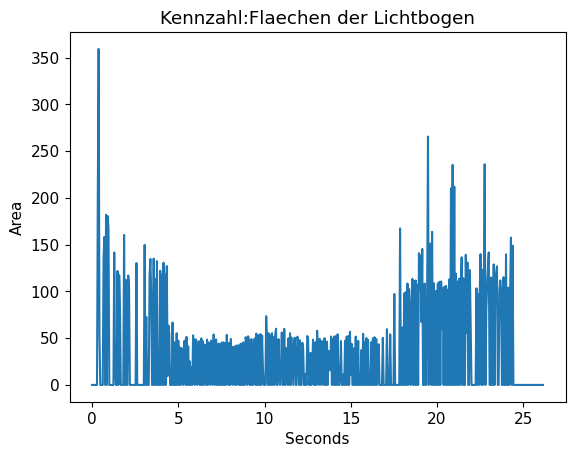

In [30]:
#Flächen
plt.plot(seconds, lichtbogen_area_mm)
plt.xlabel('Seconds')
plt.ylabel('Area')
plt.title('Kennzahl:Flaechen der Lichtbogen')
plt.show()

<IPython.core.display.Javascript object>


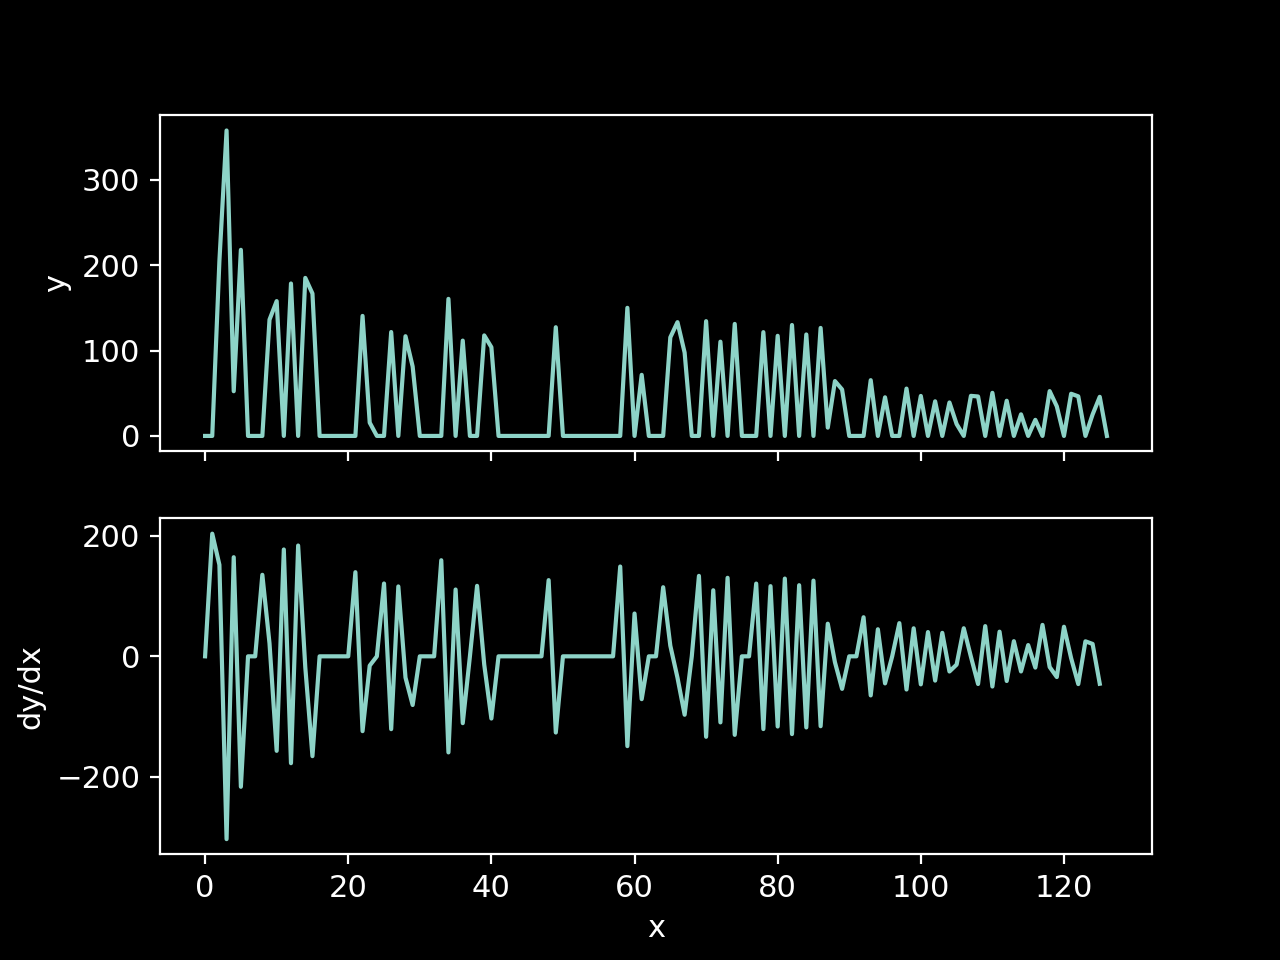

In [132]:
# 1.ABTEILUNG：
dy_lichtbogen_area_mm = get_abteilung_diagramm(lichtbogen_area_mm)
xachse = [i for i in range(len(lichtbogen_area_mm))] # [in Sekunde]
# plott
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(xachse, lichtbogen_area_mm)
ax[0].set_ylabel('y')
ax[1].plot(xachse[:-1], dy_lichtbogen_area_mm)
ax[1].set_xlabel('x')
ax[1].set_ylabel('dy/dx')
plt.show()

**Spritzeranzahl:**

<IPython.core.display.Javascript object>


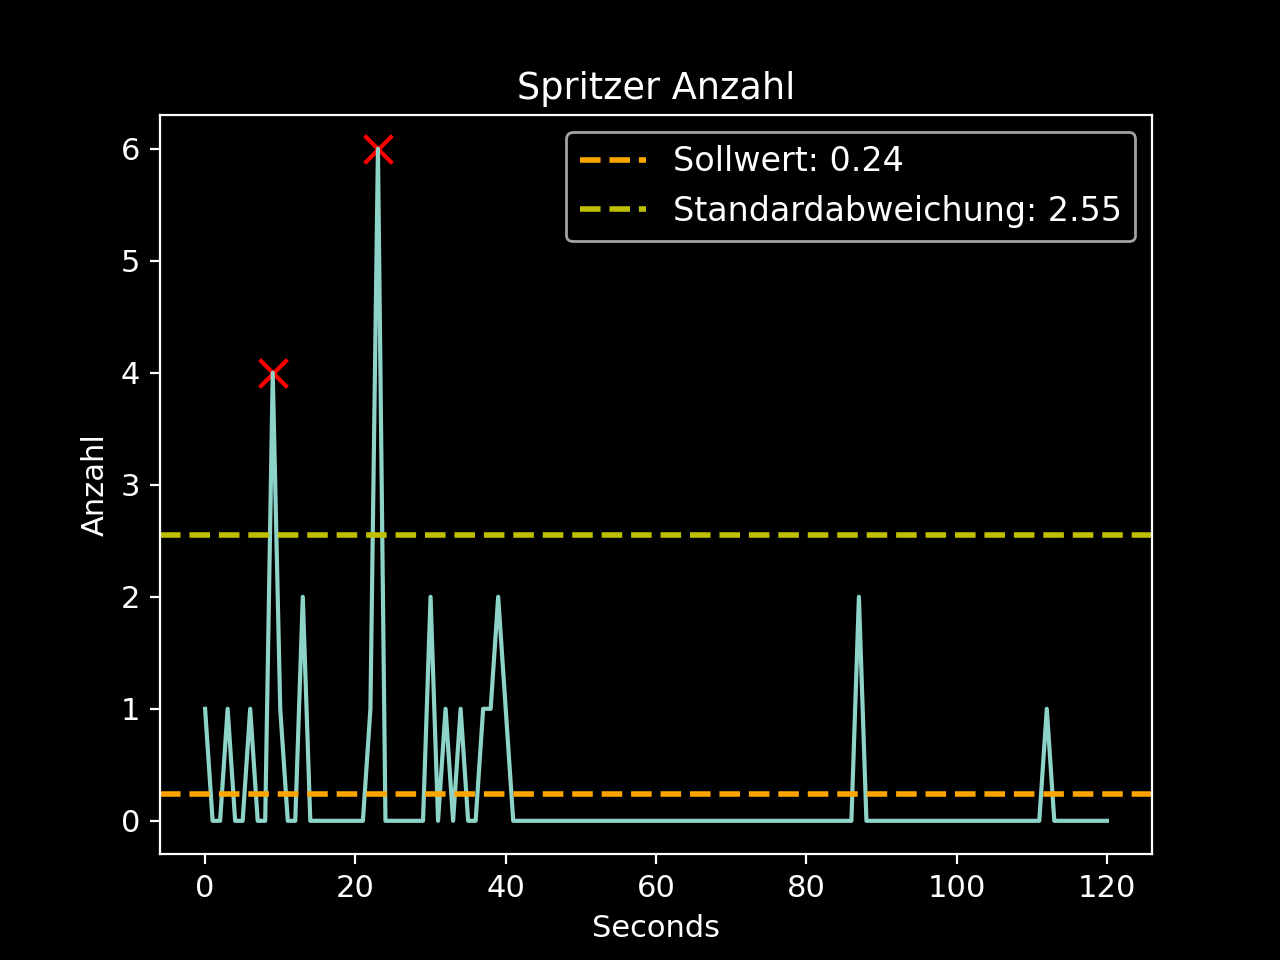

In [139]:
#Spritzeranzahl
re = get_Spritzer_anzahl(results2) # neu
average = sum(re) / len(re)
std_dev = np.std(re)
upp_lim = average + 3 * std_dev
unt_lim = average - 3 * std_dev
owg = average + 2 * std_dev
uwg = average - 2 * std_dev
seconds = [i for i in range(len(get_Spritzer_anzahl(results2)))] # neu
plt.plot(seconds, get_Spritzer_anzahl(results2))  # neu
plt.axhline(y=average, color='orange', linestyle='--', linewidth=2, label=f'Sollwert: {average:.2f}')
plt.axhline(y=upp_lim, color='y', linestyle='--', linewidth=2, label=f'Standardabweichung: {upp_lim:.2f}')
for i, value in enumerate(re):
    if value > upp_lim or value < unt_lim:
        plt.scatter(seconds[i], re[i], s=100, color='red', marker='x')
        rounded_value = round(value, 5)
        # 向下取整
        floor_value = math.floor(value)
        # 向上取整
        ceil_value = math.ceil(value)

        l_value = rounded_value

        plt.text(seconds[i] + 0.1, re[i],f'',  fontsize=9, color='red')
plt.xlabel('Seconds')
plt.ylabel('Anzahl')
plt.title('Spritzer Anzahl')
plt.legend(loc='best', fontsize=12)
plt.show()

[Top of Notebook](#divtop)

<a id='step4'></a>
#### **Step 4: Einheite: Pixelwert zu MM transportieren**

Vereinen:X-Achse:time or frame, Y-Achse: mm

**MethodeI: Berechnungen basierend auf Kamerasystemdaten**

In [132]:
### Step 1:Eingabe der Daten von Kamerasystem
#Bennweite:
f= 5 #mm
# Anstand zwischen Kamera und TCP:
g=   400 # mm
# Sensor Größe:
sensor = 1/4


### Step 2:
# Durch Tabelle :
# Öffnungswinkel:
winkel =49# Grad


### Step 3:
# Umrechnung:
# winkel = arctan(x / g ) -> x = tan(winkel) * g
radians = math.radians(winkel)
x = math.tan(radians)*g # mm


### Step 4:
# Ergebnisse:
# Abstand Pro Pixel:
K = x/1024

print(K)

0.4493626590707067


**Methode II: Referenzobjektauswahl- Brenner**

##### Kx=0.0746
##### Ky=0.0736

Weitere Details zur Berechnung von Kx und Ky sieht im Bericht

[Top of Notebook](#divtop)

<a id='step5'></a>
#### **Step 5: animation with matplotlib**

<div class="alert alert-block" style="background-color: #90EE90">
<font color=green>

#### Recherche:
    
'''
animation plot:
https://www.youtube.com/watch?v=51rCh2Do2EE ; https://www.youtube.com/watch?v=7RgoHTMbp4A
'''
    
'''
Matplot animation tutorien:
https://www.bilibili.com/video/BV1Jx411L7LU/?spm_id_from=333.337.search-card.all.click&vd_source=74d927a7b5f727fcbc4616c5397ea7ff
'''
   
</font> 
    
</div>

**Einzel animation**

In [36]:
# Style der Plot:
plt.style.use('dark_background')

Schmelzbadlänge:

<IPython.core.display.Javascript object>


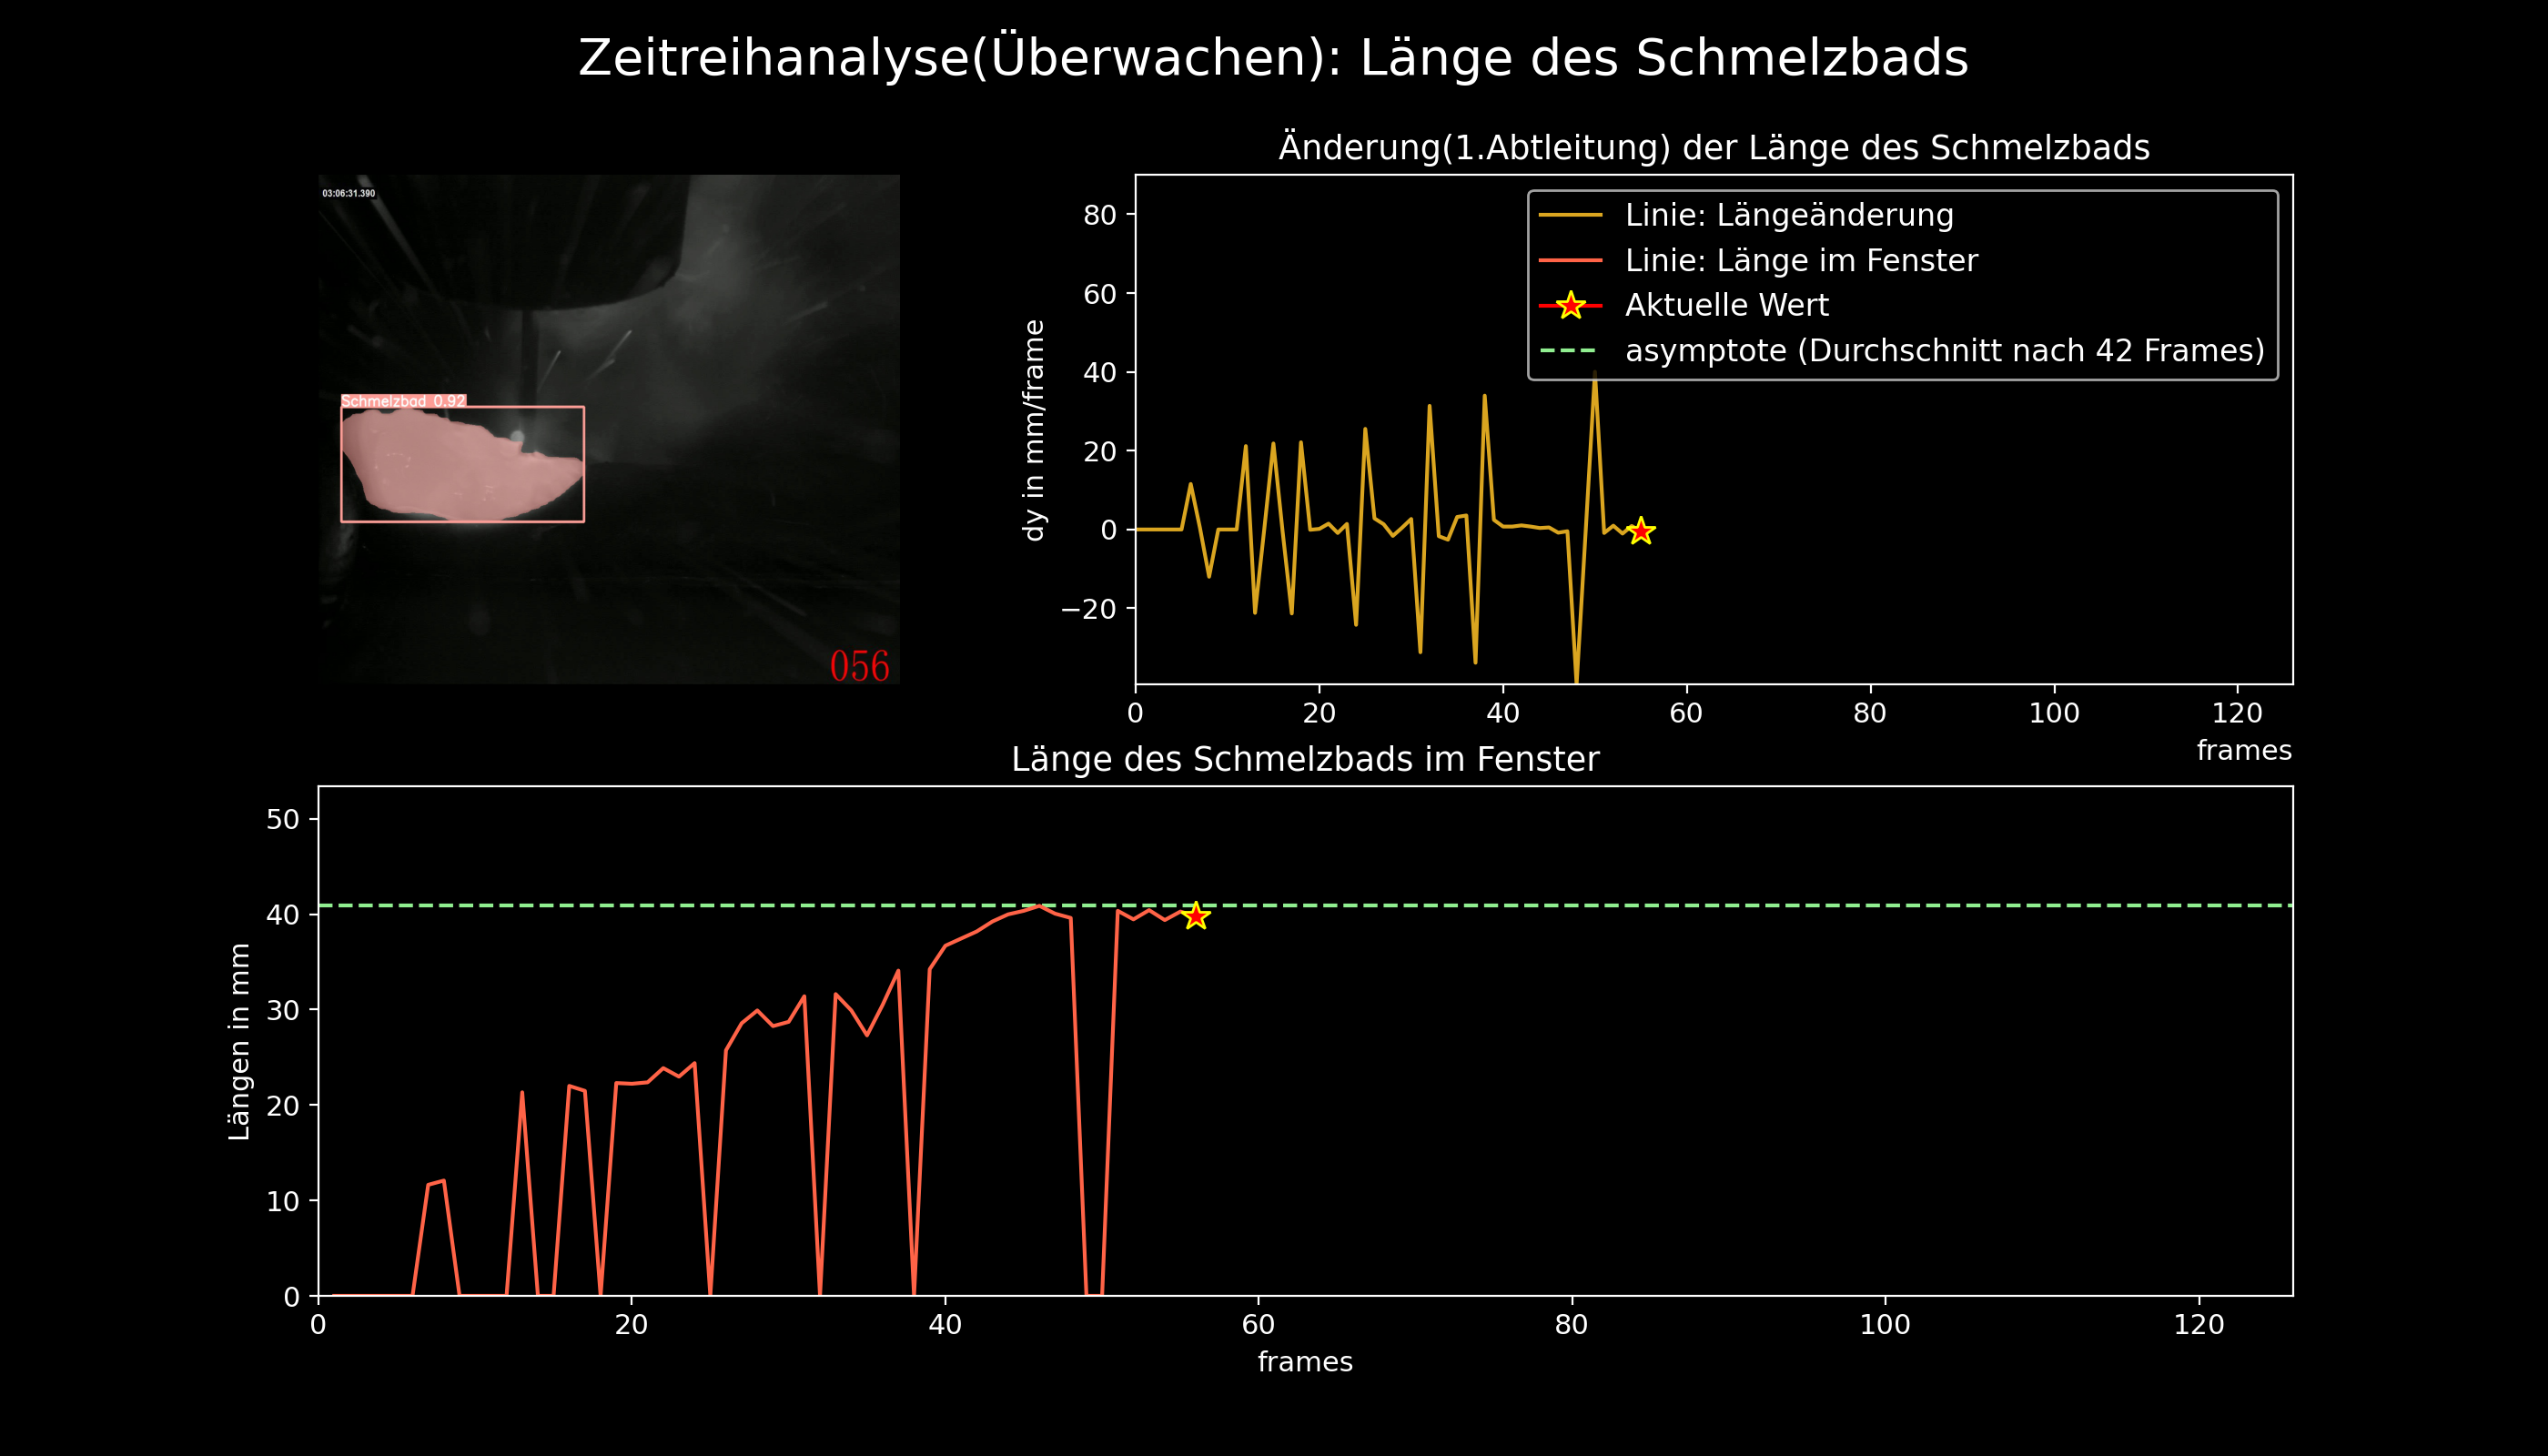

In [128]:
'''
Hier soll nach Entpräsentration weitermachen: Es werden objektorientierte Programme sowie Kapselung erstellt.
'''
%matplotlib notebook
##### __init__:############################
# Setup figure and subplots
f0 = figure(num = 0, figsize = (14, 8))
f0.suptitle("Zeitreihanalyse(Überwachen): Länge des Schmelzbads", fontsize=20)
ax01 = subplot2grid((2, 3), (0, 0))
ax02 = subplot2grid((2, 5), (0, 2),colspan=3)
ax03 = subplot2grid((2, 1), (1, 0))

# Set titles,lim,label of subplots
ax01.set_title('Video_152743.avi von Sampel_1 ', fontsize=12)
ax02.set_title('Änderung(1.Abtleitung) der Länge des Schmelzbads')
ax03.set_title('Länge des Schmelzbads im Fenster')

ax02.set_xlim(min(xachse),max(xachse))
ax02.set_ylim(min(dy_schmelzbad_laenge_mm),max(dy_schmelzbad_laenge_mm)+50)
ax03.set_xlim(min(xachse),max(xachse))
ax03.set_ylim(min(schmelzbad_laenge_mm),max(schmelzbad_laenge_mm)+10)

ax02.set_xlabel("frames", loc = 'right')
ax02.set_ylabel("dy in mm/frame")
ax03.set_xlabel("frames")
ax03.set_ylabel("Längen in mm") 
# Asymptote:
converge_value = np.mean(schmelzbad_laenge_mm[40:])  
converge_line = ax03.axhline(y=converge_value, color='lightgreen', linestyle='--', label=f'asymptote (Durchschnitt nach 42 Frames)')
#plt.ax03hline(y=50, color='y', linestyle='--', linewidth=2, label=f'Standardabweichung: {50:.2f}')

# set plots
xachse = [i for i in range(len(schmelzbad_laenge_mm))]
dx = xachse[:-1]

p02, = ax02.plot(dx,dy_schmelzbad_laenge_mm,'goldenrod', label=f'Linie: Längeänderung')
line2 = Line2D([], [], color='r', marker='*', markersize=12, markeredgecolor='yellow', label=f'Aktuelle Wert')
ax02.add_line(line2)

p03, = ax03.plot(xachse,schmelzbad_laenge_mm,'tomato', label=f'Linie: Länge im Fenster')
line3 = Line2D([], [], color='r', marker='*', markersize=12, markeredgecolor='yellow')
ax03.add_line(line3)

##### __Animetion__:############################
def updateData(i):
    head=i
    # Video:
    img_dir = '/Users/xuhao/runs/segment/predict10'
    img_files = sorted(os.listdir(img_dir))
    img_file = img_files[i]
    img_path = os.path.join(img_dir, img_file)
    img_data = plt.imread(img_path)
    ax01.clear()
    ax01.axis('off')
    # Set aspect ratio to "auto" to allow the image to scale in the x-axis
    ax01.set_aspect('auto')
    
    # Display the image without changing its height
    ax01.imshow(img_data, aspect='auto')
    #ax01.imshow(img_data)
    #Lichtbogen:
    p02.set_data(dx[0:0+i],dy_schmelzbad_laenge_mm[0:0+i])
    line2.set_data(dx[head-1], dy_schmelzbad_laenge_mm[head-1])
    #Schmelzbad:
    p03.set_data(xachse[1:1+i],schmelzbad_laenge_mm[1:1+i])
    line3.set_data(xachse[head], schmelzbad_laenge_mm[head])
    ax02.legend(handles=[p02,p03,line2,converge_line], loc='best', fontsize=12)
    return ax01, p02, p03

##### __Run__:############################
# Durchfuehren der Animation:
simulation = animation.FuncAnimation(f0, updateData, blit=True, frames=len(schmelzbad_area), interval=10, repeat=False)

##### __Save__:############################
Writer = animation.writers['ffmpeg']
writer = Writer(fps=2, metadata=dict(artist='Me'), bitrate=10000)
simulation.save('Laenge des Schmelzbads.mp4', writer=writer)
# show
plt.show()

Flächen der Lichtbogen:

<IPython.core.display.Javascript object>


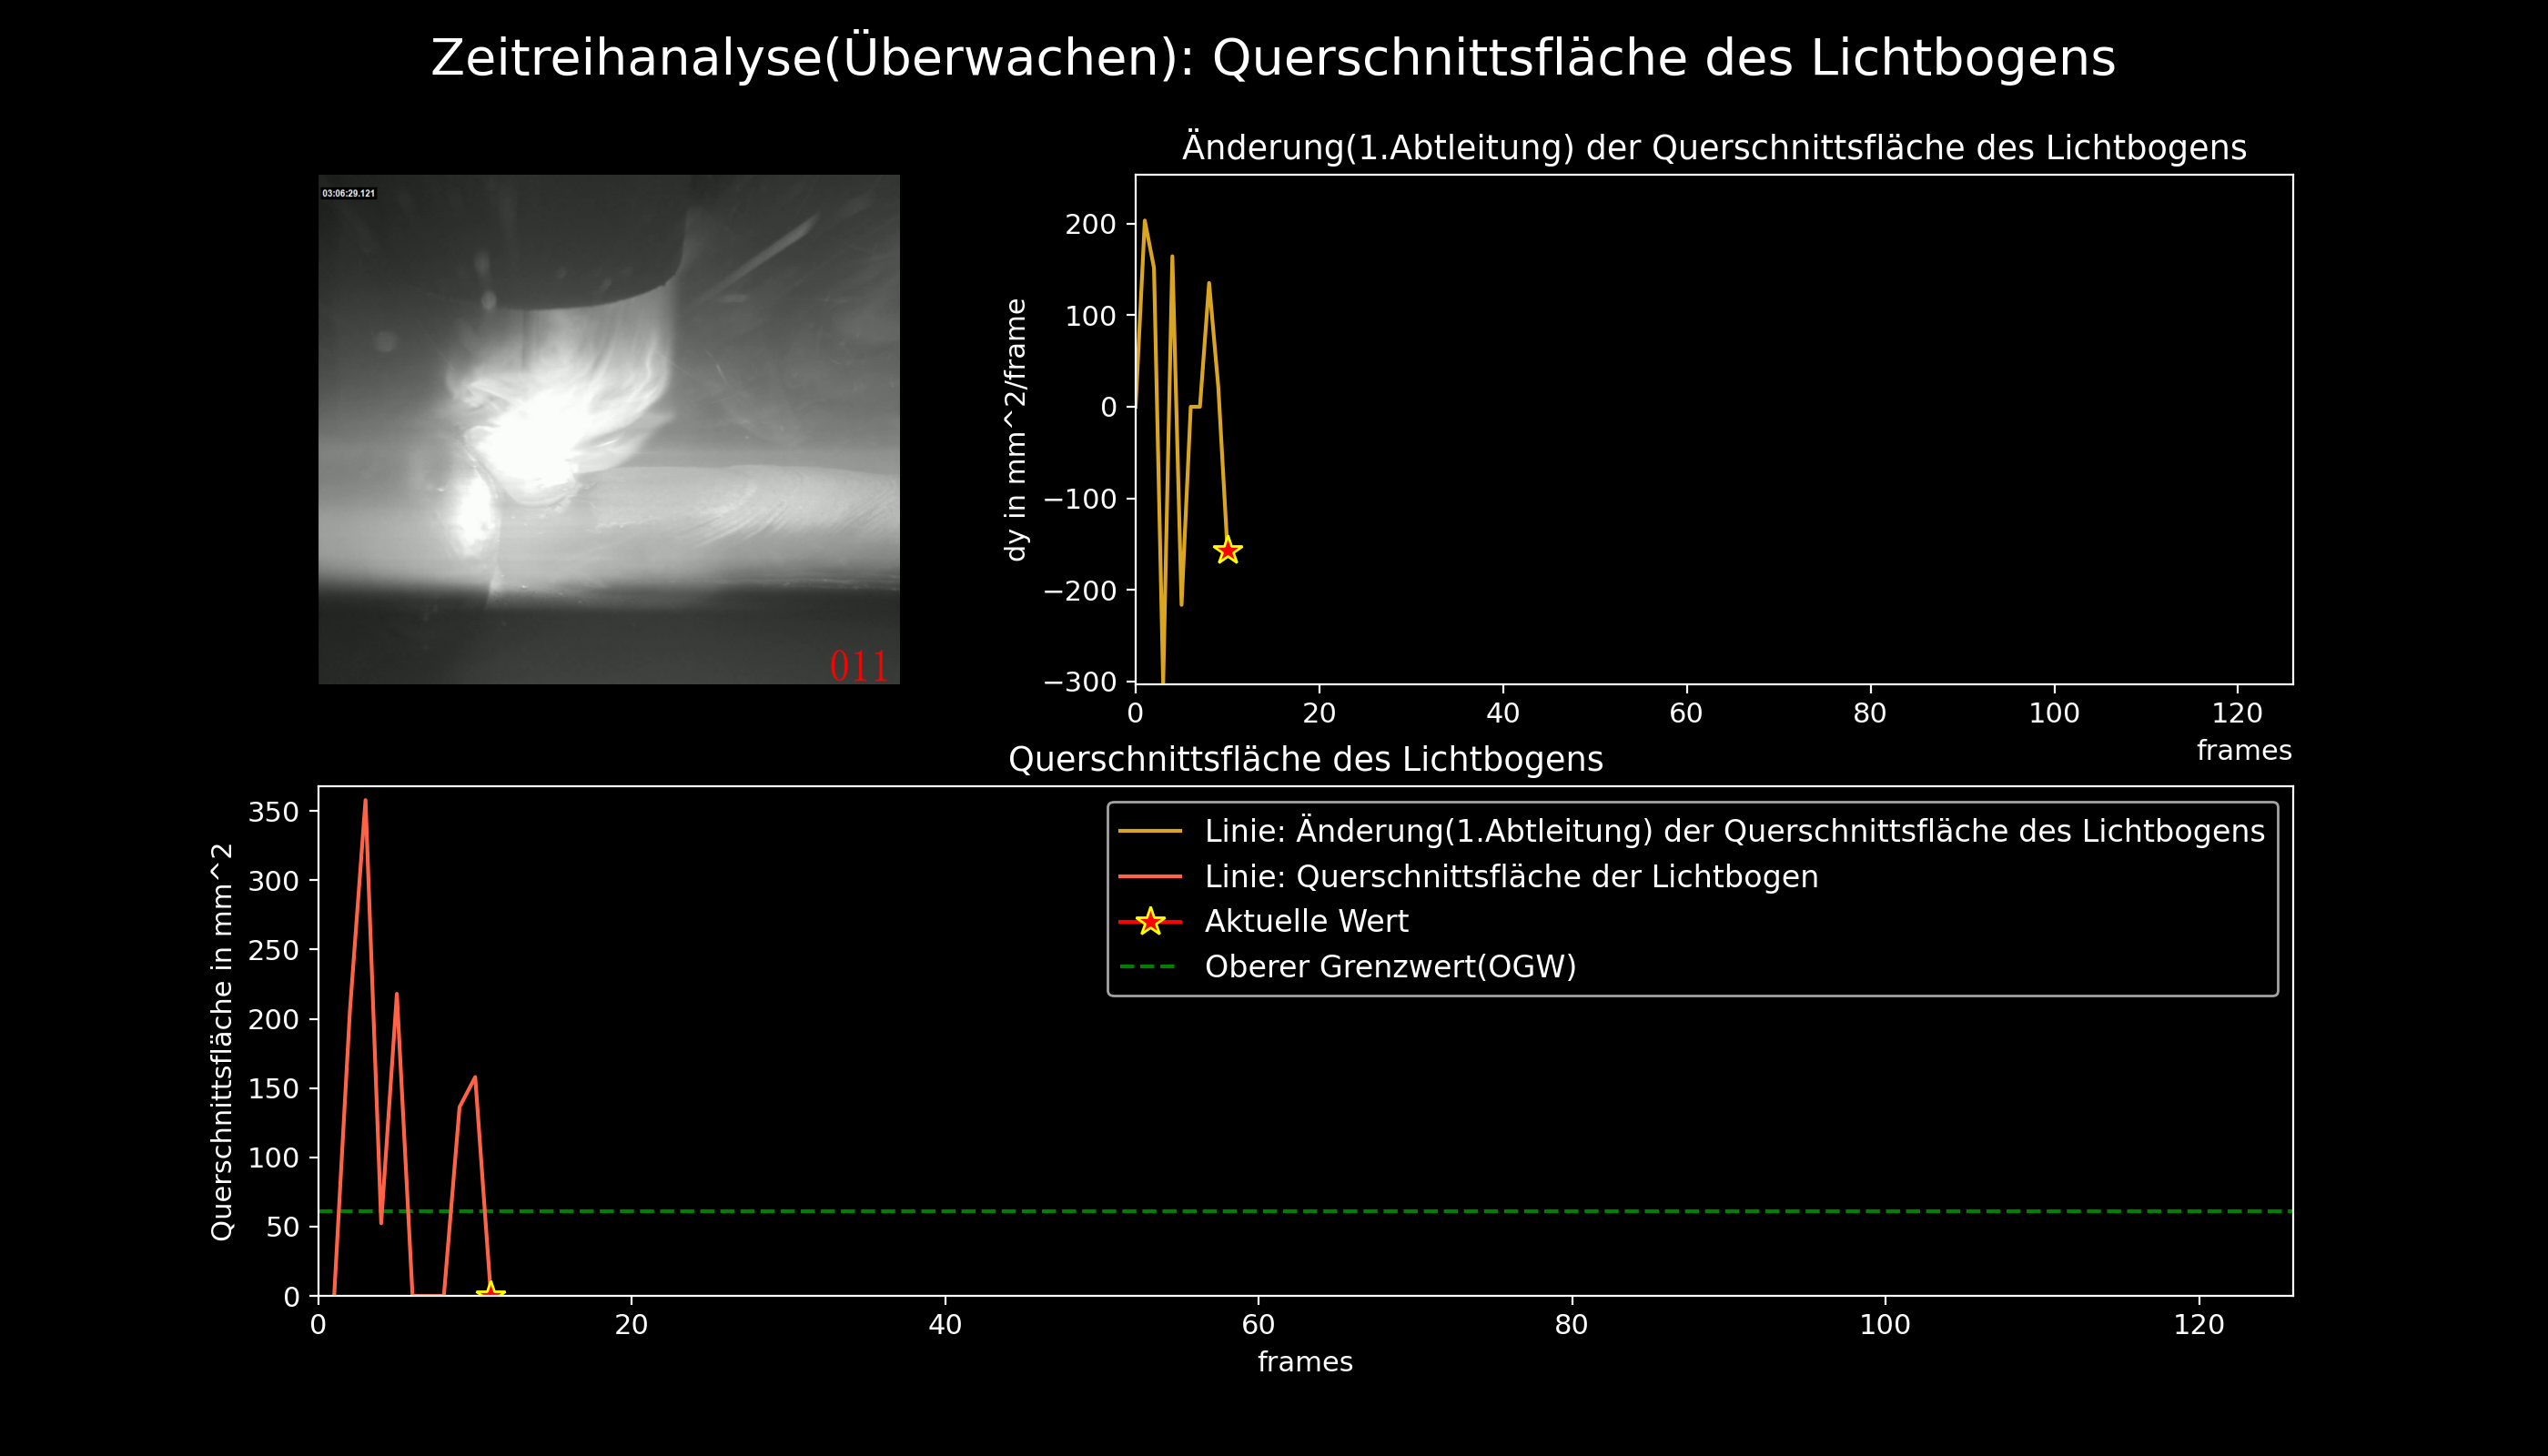

In [134]:
'''
Hier soll nach Entpräsentration weitermachen: Es werden objektorientierte Programme sowie Kapselung erstellt.
'''
%matplotlib notebook
##### __init__:############################
# Setup figure and subplots
f0 = figure(num = 0, figsize = (14, 8))
f0.suptitle("Zeitreihanalyse(Überwachen): Querschnittsfläche des Lichtbogens", fontsize=20)
ax01 = subplot2grid((2, 3), (0, 0))
ax02 = subplot2grid((2, 5), (0, 2),colspan=3)
ax03 = subplot2grid((2, 1), (1, 0))

# Set titles,lim,label of subplots
ax01.set_title('Video_152743.avi von Sampel_1 ', fontsize=12)
ax02.set_title('Änderung(1.Abtleitung) der Querschnittsfläche des Lichtbogens')
ax03.set_title('Querschnittsfläche des Lichtbogens')

ax02.set_xlim(min(xachse),max(xachse))
ax02.set_ylim(min(dy_lichtbogen_area_mm),max(dy_lichtbogen_area_mm)+50)
ax03.set_xlim(min(xachse),max(xachse))
ax03.set_ylim(min(lichtbogen_area_mm),max(lichtbogen_area_mm)+10)

ax02.set_xlabel("frames", loc = 'right')
ax02.set_ylabel("dy in mm^2/frame")
ax03.set_xlabel("frames")
ax03.set_ylabel("Querschnittsfläche in mm^2") 

converge_value = np.mean(lichtbogen_area_mm[42:])   # Obere Precontrol Line(OPL)：
converge_line = ax03.axhline(y=converge_value*2, color='green', linestyle='--', label=f'Oberer Grenzwert(OGW)')

# set plots
xachse = [i for i in range(len(lichtbogen_area_mm))]
dx = xachse[:-1]
p02, = ax02.plot(dx,dy_lichtbogen_area_mm,'goldenrod', label=f'Linie: Änderung(1.Abtleitung) der Querschnittsfläche des Lichtbogens')
line2 = Line2D([], [], color='r', marker='*', markersize=12, 
               markeredgecolor='yellow', label=f'Aktuelle Wert')
ax02.add_line(line2)

p03, = ax03.plot(xachse,lichtbogen_area_mm,'tomato', label=f'Linie: Querschnittsfläche der Lichtbogen')
line3 = Line2D([], [], color='r', marker='*', markersize=12, 
               markeredgecolor='yellow', label=f'Aktuelle Wert')
ax03.add_line(line3)
#ax02.set_facecolor("#D2F1DC")

##### __Animetion__:############################
def updateData(i):
    head=i
    # Video:
    img_dir = '/Users/xuhao/runs/segment/predict10'
    img_files = sorted(os.listdir(img_dir))
    img_file = img_files[i]
    img_path = os.path.join(img_dir, img_file)
    img_data = plt.imread(img_path)
    ax01.clear()
    ax01.axis('off')
    # Set aspect ratio to "auto" to allow the image to scale in the x-axis
    ax01.set_aspect('auto')
    
    # Display the image without changing its height
    ax01.imshow(img_data, aspect='auto')
    #ax01.imshow(img_data)
    #Lichtbogen:
    p02.set_data(dx[0:0+i],dy_lichtbogen_area_mm[0:0+i])
    line2.set_data(dx[head-1], dy_lichtbogen_area_mm[head-1])
    #Schmelzbad:
    p03.set_data(xachse[1:1+i],lichtbogen_area_mm[1:1+i])
    line3.set_data(xachse[head], lichtbogen_area_mm[head])
    ax03.legend(handles=[p02,p03,line2,converge_line], loc='best', fontsize=12)
    return ax01, p02, p03

##### __Run__:############################
# Durchfuehren der Animation:
simulation = animation.FuncAnimation(f0, updateData, blit=True, frames=len(lichtbogen_area_mm), interval=10, repeat=False)

##### __Save__:############################
Writer = animation.writers['ffmpeg']
writer = Writer(fps=2, metadata=dict(artist='Me'), bitrate=10000)
simulation.save('Querschnittsflaeche des Lichtbogens.mp4', writer=writer)

# show
plt.show()

In [143]:
len(dy_schmelzbad_laenge_mm), len(schmelzbad_laenge_mm)
xachse = [i for i in range(len(spritzer_anzahl))]

Anzahl der Spritzer:

<IPython.core.display.Javascript object>


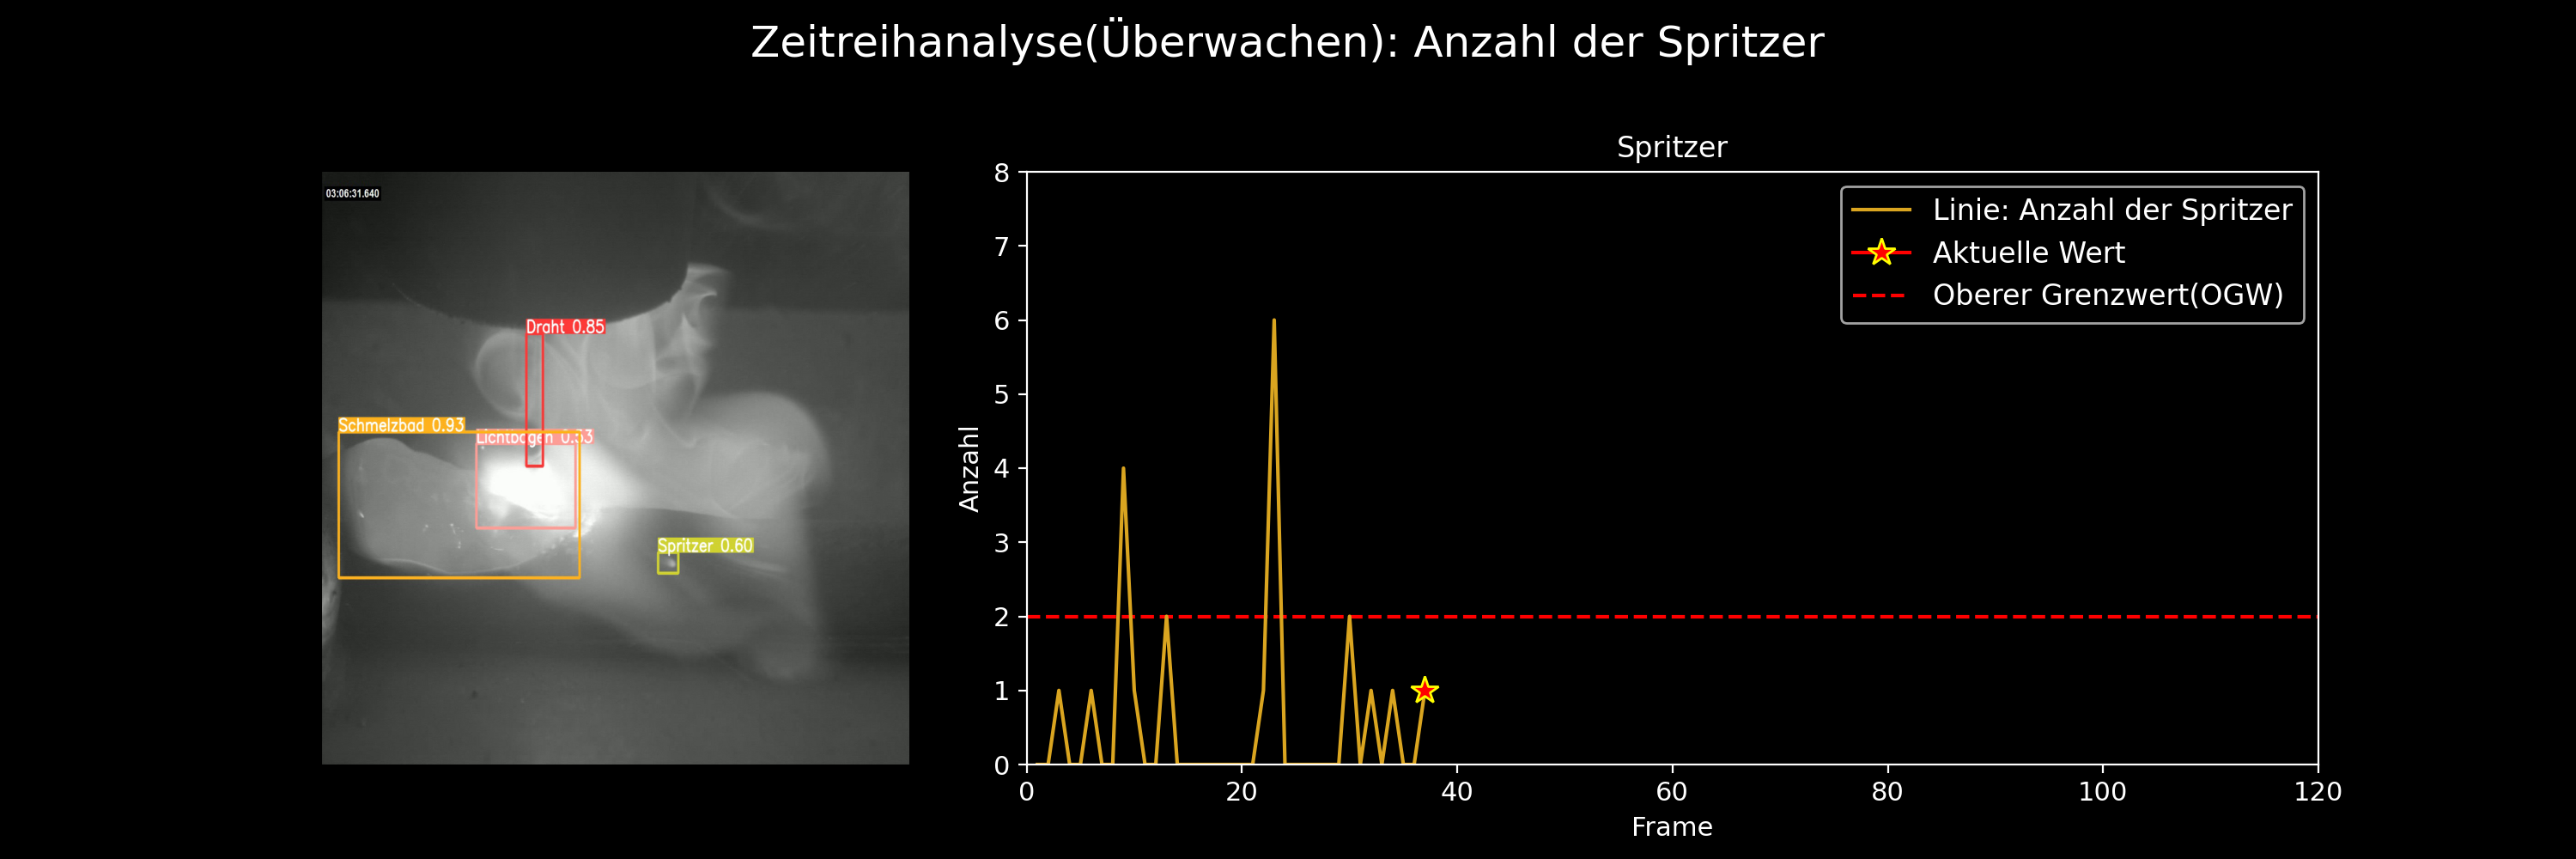

In [144]:
'''
Hier soll nach Entpräsentration weitermachen: Es werden objektorientierte Programme sowie Kapselung erstellt.
'''
%matplotlib notebook
import matplotlib.pyplot as plt
#%matplotlib inline
##### __init__:###############################################
# Setup figure and subplots#
f0 = figure(num = 0, figsize = (15, 5))
f0.suptitle("Zeitreihanalyse(Überwachen): Anzahl der Spritzer", fontsize=18)
f0.subplots_adjust(top=0.8)
ax01 = subplot2grid((1, 3), (0, 0),colspan=1)
ax02 = subplot2grid((1, 3), (0, 1),colspan=2)

# Set titles of subplots

ax01.set_title('Video_152743.avi von Sampel_1 ', fontsize=12)
ax02.set_title('Spritzer', fontsize=12)

ax02.set_xlim(min(xachse),max(xachse))
ax02.set_ylim(min(spritzer_anzahl),max(spritzer_anzahl)+2)

# set label names
ax02.set_xlabel("Frame")
ax02.set_ylabel("Anzahl")
converge_line = ax02.axhline(y=2, color='r', linestyle='--', label=f'Oberer Grenzwert(OGW)')

# set plots
xachse = [i for i in range(len(spritzer_anzahl))]
p02, = ax02.plot(xachse,spritzer_anzahl,'goldenrod', label=f'Linie: Anzahl der Spritzer')
line2 = Line2D([], [], color='r', marker='*', markersize=12, markeredgecolor='yellow', label=f'Aktuelle Wert')
ax02.add_line(line2)

##### __Animetion__: wieder definieren############################
def updateData(i):
    head=i
    # Video:
    img_dir = '/Users/xuhao/runs/detect/predict7'
    img_files = sorted(os.listdir(img_dir))
    img_file = img_files[i]
    img_path = os.path.join(img_dir, img_file)
    img_data = plt.imread(img_path)
    ax01.clear()
    ax01.axis('off')
    # Set aspect ratio to "auto" to allow the image to scale in the x-axis
    ax01.set_aspect('auto')
    # Display the image without changing its height
    ax01.imshow(img_data, aspect='auto')
    #Lichtbogen:
    p02.set_data(xachse[1:1+i],spritzer_anzahl[1:1+i])
    line2.set_data(xachse[head], spritzer_anzahl[head])
    plt.legend(handles=[p02,line2,converge_line], loc='best', fontsize=12)
    return ax01, p02

##### __Run__:############################
# Durchfuehren der Animation:
simulation = animation.FuncAnimation(f0, updateData, blit=True, frames=len(spritzer_anzahl), interval=10, repeat=False)

##### __Save__:############################
Writer = animation.writers['ffmpeg']
writer = Writer(fps=2, metadata=dict(artist='Me'), bitrate=10000)
simulation.save('spritzer.mp4', writer=writer)

# show

plt.show()

In [921]:
len(spritzer_anzahl)


121

**Subplot: Alle zusammen**

<IPython.core.display.Javascript object>


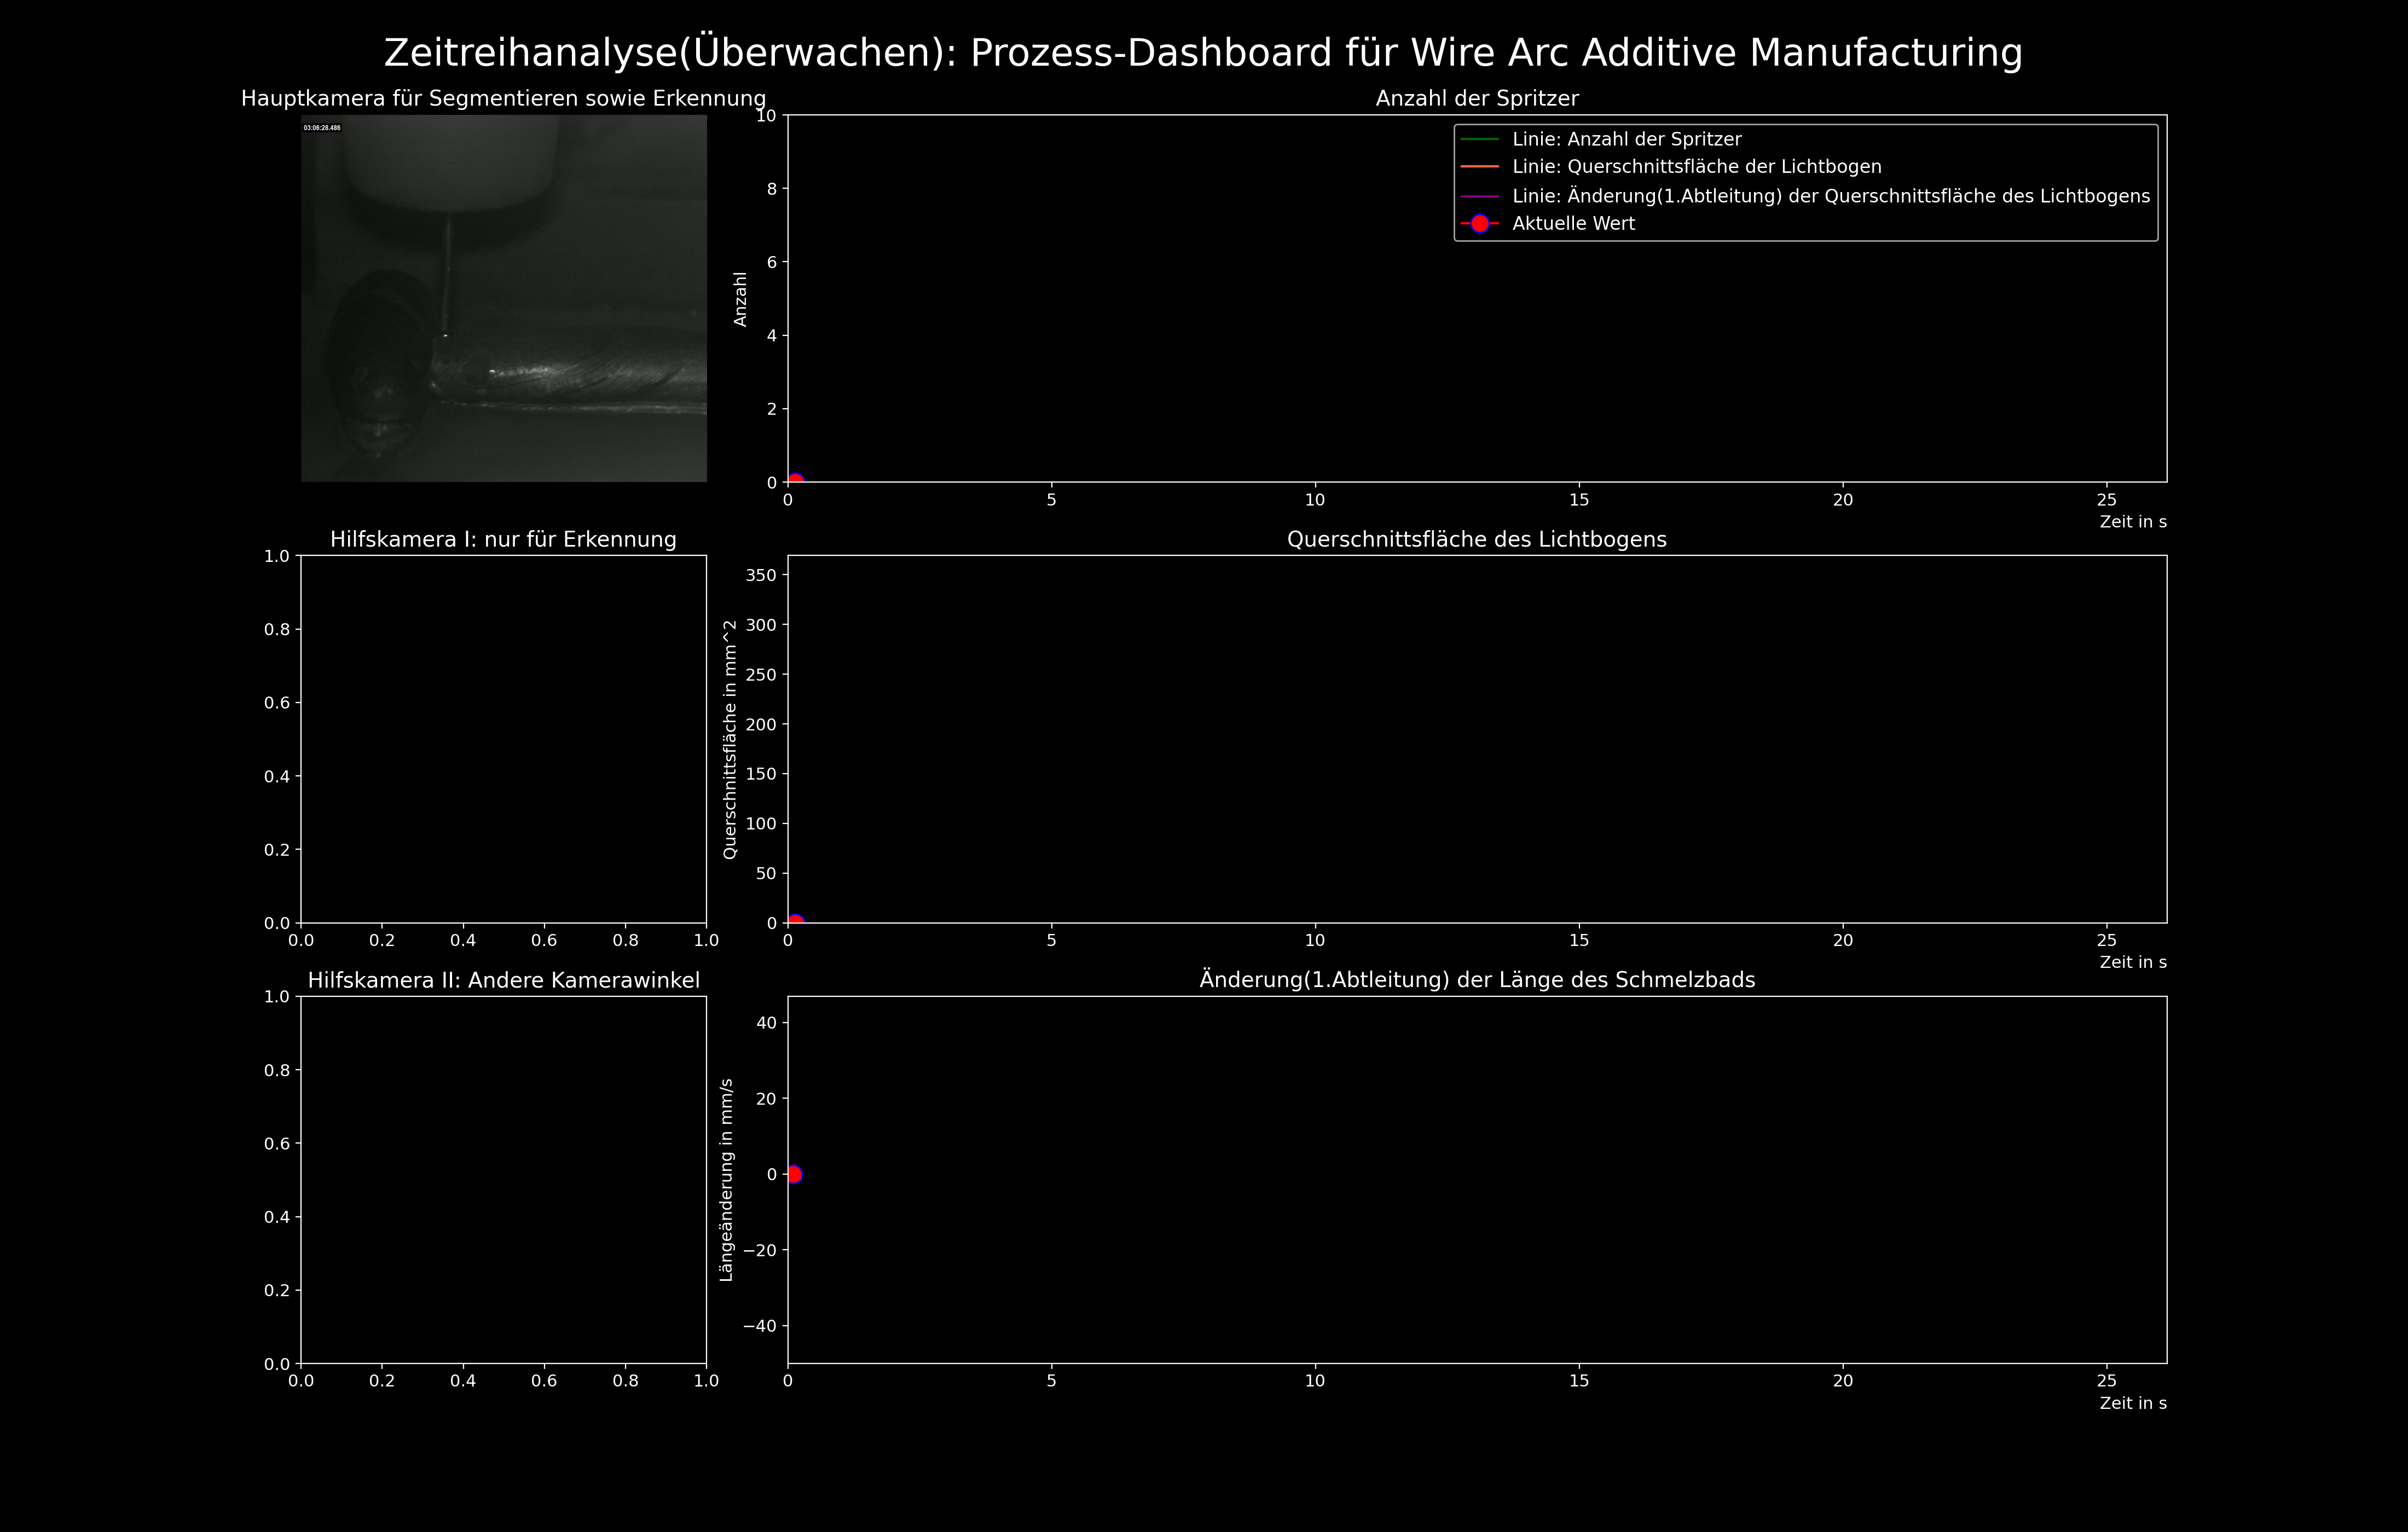

In [117]:
'''
Hier soll nach Entpräsentration weitermachen: Es werden objektorientierte Programme sowie Kapselung erstellt.
'''
#from matplotlib import pyplot as plt
#from matplotlib import animation
#import matplotlib.animation as animation
import numpy
from matplotlib.pylab import *
from mpl_toolkits.axes_grid1 import host_subplot
import matplotlib.animation as animation
##### __init__:############################
#font = {'size'   : 9}
# Setup figure and subplots
f0 = plt.figure(num = 0, figsize = (22, 14))
f0.subplots_adjust(top=0.925)
f0.suptitle("Zeitreihanalyse(Überwachen): Prozess-Dashboard für Wire Arc Additive Manufacturing", fontsize=25)
plt.tight_layout()
ax01 = subplot2grid((3, 4), (0, 0))
ax02 = subplot2grid((3, 4), (1, 0))
ax03 = subplot2grid((3, 4), (2, 0))
ax04 = subplot2grid((3, 4), (0, 1),colspan=3) 
ax05 = subplot2grid((3, 4), (1, 1),colspan=3)
ax06 = subplot2grid((3, 4), (2, 1),colspan=3)

# Set titles,lim,label of subplots
ax01.set_title('Hauptkamera für Segmentieren sowie Erkennung', fontsize=14)
ax02.set_title('Hilfskamera I: nur für Erkennung', fontsize=14)
ax03.set_title('Hilfskamera II: Andere Kamerawinkel', fontsize=14)
ax04.set_title('Anzahl der Spritzer', fontsize=14)
ax05.set_title('Querschnittsfläche des Lichtbogens', fontsize=14)
ax06.set_title('Änderung(1.Abtleitung) der Länge des Schmelzbads', fontsize=14)

#converge_line04 = ax04.axhline(y=2, color='r', linestyle='--', label=f'Oberer Grenzwert(OGW)')

ax04.set_xlim(min(xachse),max(xachse))
ax04.set_ylim(min(spritzer_anzahl),max(spritzer_anzahl)+2)
ax05.set_xlim(min(xachse),max(xachse))
ax05.set_ylim(min(lichtbogen_area_mm),max(lichtbogen_area_mm)+10)
ax06.set_xlim(min(xachse),max(xachse))
ax06.set_ylim(-50,max(schmelzbad_laenge_mm))

ax04.set_xlabel("Zeit in s", loc = 'right')
ax04.set_ylabel("Anzahl")
ax05.set_xlabel("Zeit in s", loc = 'right')
ax05.set_ylabel("Querschnittsfläche in mm^2") 
ax06.set_xlabel("Zeit in s", loc = 'right')
ax06.set_ylabel("Längeänderung in mm/s") 


# set plots
xachse = [i/21 for i in range(len(schmelzbad_laenge_mm))]
dx = xachse[:-1]
p04, = ax04.plot(xachse,spritzer_anzahl,'darkgreen', label=f'Linie: Anzahl der Spritzer')
line4 = Line2D(
            [], [], color='r', marker='o', markersize=12, markeredgecolor='b', label=f'Aktuelle Wert')
ax04.add_line(line4)

p05, = ax05.plot(xachse,lichtbogen_area_mm,'tomato', label=f'Linie: Querschnittsfläche der Lichtbogen')
line5 = Line2D(
            [], [], color='r', marker='o', markersize=12, markeredgecolor='b', label=f'Aktuelle Wert')
ax05.add_line(line5)

p06, = ax06.plot(dx,dy_schmelzbad_laenge_mm,'purple', label=f'Linie: Änderung(1.Abtleitung) der Querschnittsfläche des Lichtbogens')
line6 = Line2D(
            [], [], color='r', marker='o', markersize=12, markeredgecolor='b', label=f'Aktuelle Wert')
ax06.add_line(line6)
#ax02.set_facecolor("#D2F1DC")

##### __Animetion__:############################
def updateData(i):
    head=i
    # Video:
    img_dir = '/Users/xuhao/runs/segment/predict9'
    img_files = sorted(os.listdir(img_dir))
    img_file = img_files[i]
    img_path = os.path.join(img_dir, img_file)
    img_data = plt.imread(img_path)
    #ax01.clear()
    ax01.axis('off')
    # Set aspect ratio to "auto" to allow the image to scale in the x-axis
    ax01.set_aspect('auto')
    # Display the image without changing its height
    ax01.imshow(img_data, aspect='auto')
    
    #Spritzer:
    p04.set_data(xachse[1:1+i],spritzer_anzahl[1:1+i])
    line4.set_data(xachse[head], spritzer_anzahl[head])
    #line4.set_label('Anzahl der SPritzer')
    
    #Lichtbogen:
    p05.set_data(xachse[1:1+i],lichtbogen_area_mm[1:1+i])
    line5.set_data(xachse[head], lichtbogen_area_mm[head])
    
    #Schmelzbad:
    p06.set_data(dx[:0+i],dy_schmelzbad_laenge_mm[:0+i])
    line6.set_data(dx[head-1], dy_schmelzbad_laenge_mm[head-1])
    
    ax04.legend(handles=[p04, p05, p06,line4],loc='best', fontsize=12)
    return  ax01, p04, p05, p06 #,ax01,
##### __Run__:############################
# Durchfuehren der Animation:
simulation = animation.FuncAnimation(f0, updateData, blit=True, frames=len(schmelzbad_area), interval=10, repeat=False)

##### __Save__:############################
#Writer = animation.writers['ffmpeg']
#writer = Writer(fps=21, metadata=dict(artist='Me'), bitrate=10000)
#simulation.save('Prozess-Dashboard.mp4', writer=writer)

# show
plt.show()

In [60]:
img_dir = '/Users/xuhao/runs/segment/predict9'
img_files = sorted(os.listdir(img_dir))
img_file = img_files[0]
img_file

'_0358.jpg'

**Video machen:**
Das Video wird bildweise in Bilder umgewandelt

In [108]:
def save_all_frames(video_path, dir_path, basename, ext='jpg'):
    """This function also removes the duplicate frames.
    
    From: https://note.nkmk.me/en/python-opencv-video-to-still-image/
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return

    os.makedirs(dir_path, exist_ok=True)
    base_path = os.path.join(dir_path, basename)

    digit = len(str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))))

    n = 0

    while True:
        ret, frame = cap.read()
        if ret:
            cv2.imwrite('{}_{}.{}'.format(base_path, str(n).zfill(digit), ext), frame)
            n += 1
        else:
            return

Der Pfad festzugelegen

In [109]:
video_file = "220615-152743-STtoST_3_6_10.avi"
head, sep, tail = video_file.partition("Sample")
frame_base_name = sep + tail
frame_base_name = frame_base_name.rstrip(".avi").replace("/", "_")
save_all_frames(video_file, './extracted_frames_no_duplicates', frame_base_name)

Das Modell wird geladen und Bilder mit Box-Rahmen werden erzeugn

In [195]:
# Schmelzbad und Lichtbogen:
if __name__ == '__main__':
# Load a model220615-152743-STtoST_3_6_10.avi
    model = YOLO("best_v8m.pt") 
# Predict with the model
    model.predict(source='extracted_frames_no_duplicates',save= True,conf=0.5,iou=0.1,boxes=True,retina_masks=True) 



    WARNING ⚠️ stream/video/webcam/dir predict source will accumulate results in RAM unless `stream=True` is passed,
    causing potential out-of-memory errors for large sources or long-running streams/videos.

    Usage:
        results = model(source=..., stream=True)  # generator of Results objects
        for r in results:
            boxes = r.boxes  # Boxes object for bbox outputs
            masks = r.masks  # Masks object for segment masks outputs
            probs = r.probs  # Class probabilities for classification outputs

image 1/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0000.jpg: 512x640 1 Schmelzbad, 698.9ms
image 2/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0001.jpg: 512x640 1 Schmelzbad, 451.8ms
image 3/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0002.jpg: 512x640 1 Schmelzbad, 430.2ms
image 4/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplica

image 61/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0060.jpg: 512x640 (no detections), 399.0ms
image 62/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0061.jpg: 512x640 (no detections), 379.2ms
image 63/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0062.jpg: 512x640 (no detections), 373.8ms
image 64/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0063.jpg: 512x640 (no detections), 373.1ms
image 65/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0064.jpg: 512x640 (no detections), 392.4ms
image 66/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0065.jpg: 512x640 (no detections), 383.9ms
image 67/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0066.jpg: 512x640 (no detections), 387.5ms
image 68/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_006

image 125/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0124.jpg: 512x640 1 Schmelzbad, 511.0ms
image 126/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0125.jpg: 512x640 1 Schmelzbad, 408.0ms
image 127/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0126.jpg: 512x640 1 Schmelzbad, 475.7ms
image 128/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0127.jpg: 512x640 1 Lichtbogen, 376.8ms
image 129/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0128.jpg: 512x640 1 Lichtbogen, 386.9ms
image 130/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0129.jpg: 512x640 1 Schmelzbad, 383.0ms
image 131/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0130.jpg: 512x640 1 Schmelzbad, 397.0ms
image 132/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0131.jpg: 512x64

image 187/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0186.jpg: 512x640 1 Lichtbogen, 1 Schmelzbad, 438.0ms
image 188/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0187.jpg: 512x640 1 Schmelzbad, 429.5ms
image 189/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0188.jpg: 512x640 1 Schmelzbad, 434.0ms
image 190/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0189.jpg: 512x640 1 Schmelzbad, 441.0ms
image 191/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0190.jpg: 512x640 1 Schmelzbad, 458.9ms
image 192/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0191.jpg: 512x640 1 Schmelzbad, 389.2ms
image 193/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0192.jpg: 512x640 1 Schmelzbad, 424.6ms
image 194/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_01

image 251/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0250.jpg: 512x640 (no detections), 396.0ms
image 252/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0251.jpg: 512x640 (no detections), 391.3ms
image 253/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0252.jpg: 512x640 (no detections), 485.6ms
image 254/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0253.jpg: 512x640 (no detections), 359.1ms
image 255/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0254.jpg: 512x640 (no detections), 485.1ms
image 256/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0255.jpg: 512x640 (no detections), 425.7ms
image 257/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_0256.jpg: 512x640 (no detections), 404.6ms
image 258/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplica

...

image 1183/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1182.jpg: 512x640 (no detections), 389.5ms
image 1184/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1183.jpg: 512x640 (no detections), 391.0ms
image 1185/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1184.jpg: 512x640 (no detections), 385.3ms
image 1186/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1185.jpg: 512x640 (no detections), 393.5ms
image 1187/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1186.jpg: 512x640 (no detections), 412.6ms
image 1188/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1187.jpg: 512x640 (no detections), 404.3ms
image 1189/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1188.jpg: 512x640 (no detections), 399.1ms
image 1190/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no

image 1246/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1245.jpg: 512x640 (no detections), 412.7ms
image 1247/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1246.jpg: 512x640 (no detections), 384.0ms
image 1248/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1247.jpg: 512x640 (no detections), 436.2ms
image 1249/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1248.jpg: 512x640 (no detections), 401.7ms
image 1250/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1249.jpg: 512x640 (no detections), 400.5ms
image 1251/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1250.jpg: 512x640 (no detections), 380.2ms
image 1252/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1251.jpg: 512x640 (no detections), 374.6ms
image 1253/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no

image 1309/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1308.jpg: 512x640 (no detections), 408.0ms
image 1310/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1309.jpg: 512x640 (no detections), 378.4ms
image 1311/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1310.jpg: 512x640 (no detections), 406.9ms
image 1312/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1311.jpg: 512x640 (no detections), 409.0ms
image 1313/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1312.jpg: 512x640 (no detections), 427.8ms
image 1314/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1313.jpg: 512x640 (no detections), 383.1ms
image 1315/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1314.jpg: 512x640 (no detections), 365.6ms
image 1316/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no

image 1372/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1371.jpg: 512x640 (no detections), 402.7ms
image 1373/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1372.jpg: 512x640 (no detections), 369.1ms
image 1374/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1373.jpg: 512x640 (no detections), 403.1ms
image 1375/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1374.jpg: 512x640 (no detections), 409.9ms
image 1376/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1375.jpg: 512x640 (no detections), 363.1ms
image 1377/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1376.jpg: 512x640 (no detections), 400.8ms
image 1378/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1377.jpg: 512x640 (no detections), 391.8ms
image 1379/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no

image 1435/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1434.jpg: 512x640 (no detections), 385.0ms
image 1436/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1435.jpg: 512x640 (no detections), 548.9ms
image 1437/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1436.jpg: 512x640 (no detections), 388.9ms
image 1438/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1437.jpg: 512x640 (no detections), 383.3ms
image 1439/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1438.jpg: 512x640 (no detections), 397.7ms
image 1440/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1439.jpg: 512x640 (no detections), 378.2ms
image 1441/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no_duplicates/_1440.jpg: 512x640 (no detections), 398.5ms
image 1442/1459 /Users/xuhao/AUT_idee_BoxPlot/outputdata/extracted_frames_no

Animation erstellen und in einem Rahmen mit Koordinatenachsen platzieren

<IPython.core.display.Javascript object>


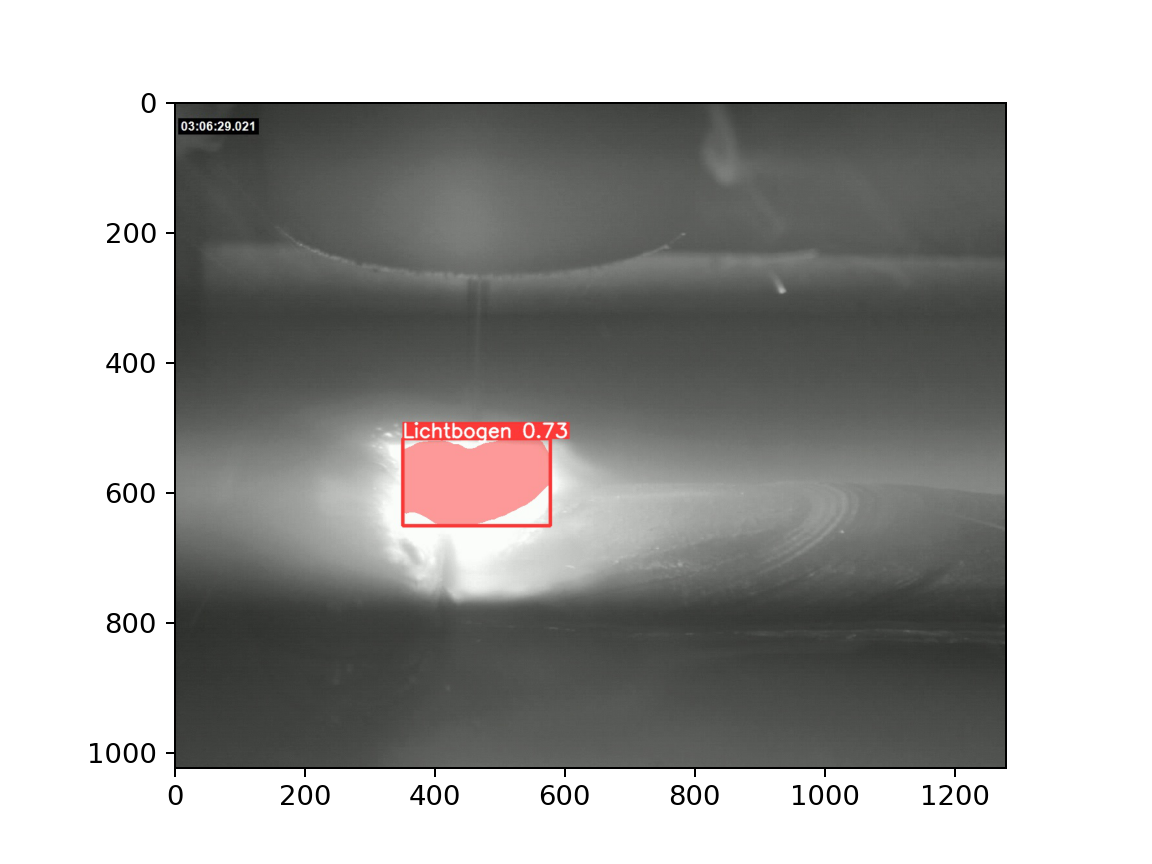

In [342]:
os.chdir("/Users/xuhao/AUT_idee_BoxPlot")

fig = plt.figure()
ax = plt.axes()

def update(frame):
    img_dir = './Bild_mit_annotation_0356_0482'
    img_files = sorted(os.listdir(img_dir))
    img_file = img_files[frame]
    img_path = os.path.join(img_dir, img_file)
    img_data = plt.imread(img_path)
    ax.clear()
    ax.imshow(img_data)
    
img_dir = './Bild_mit_annotation_0356_0482'
img_files = os.listdir(img_dir)

anim = animation.FuncAnimation(fig, update, frames=len(img_files), interval=100)

plt.show()
